# 05 — Model Training
**GridSense AI | ADS 508 MLOps for Data Science**  
**Authors:** Alexander Zhuk, Michael Ha, Mark Villanueva

This notebook trains an XGBoost binary classifier using Amazon SageMaker's **built-in XGBoost algorithm** to predict grid stress events (demand > 95 % of available renewable energy) 24 hours in advance for the ERCOT region.

**Prerequisites:**  
- Notebook `04_data_preparation.ipynb` has been run and produced `train.csv`, `validation.csv`, and `test.csv`  
- SageMaker execution role has S3 read/write access  
- Running on a SageMaker Studio kernel (Python 3, Data Science image)

**GitHub:** https://github.com/mvillanueva00/ADS-508-Final-Project

## 1. Environment Setup

In [1]:
import boto3
import sagemaker
from sagemaker import get_execution_role
from sagemaker.inputs import TrainingInput
from sagemaker.image_uris import retrieve
import pandas as pd
import numpy as np
import io
import os
import json
import time

# SageMaker session and role
session = sagemaker.Session()
role = get_execution_role()
region = boto3.Session().region_name

# S3 bucket and prefix (same bucket used in data preparation)
BUCKET = "gridsense-ai-data-team1-michaelha-2026"  #'gridsense-ai-data-team1'
OUTPUT_PREFIX = 'gridsense/models'

print(f'SageMaker version : {sagemaker.__version__}')
print(f'AWS Region        : {region}')
print(f'IAM Role          : {role}')
print(f'S3 Bucket         : {BUCKET}')

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml
SageMaker version : 2.245.0
AWS Region        : us-east-1
IAM Role          : arn:aws:iam::216685549584:role/LabRole
S3 Bucket         : gridsense-ai-data-team1-michaelha-2026


## 2. Load and Inspect Prepared Data

The CSVs produced by `04_data_preparation.ipynb` are loaded to verify shapes and class balance before uploading to S3 for training.

In [2]:
# Read split datasets directly from S3
s3_client = boto3.client('s3')

def read_csv_from_s3(bucket, key):
    obj = s3_client.get_object(Bucket=bucket, Key=key)
    return pd.read_csv(obj['Body'])

train_df      = read_csv_from_s3(BUCKET, 'train.csv')
validation_df = read_csv_from_s3(BUCKET, 'validation.csv')
test_df       = read_csv_from_s3(BUCKET, 'test.csv')

print('=== Dataset shapes ===')
print(f'Train      : {train_df.shape}')
print(f'Validation : {validation_df.shape}')
print(f'Test       : {test_df.shape}')

# Target column name
TARGET = 'grid_stress'

print('\n=== Class distribution (train) ===')
vc = train_df[TARGET].value_counts()
print(vc)
neg_count = vc.get(0, 0)
pos_count = vc.get(1, 0)
scale_pos_weight = round(neg_count / pos_count, 2) if pos_count > 0 else 1.0
print(f'\nscale_pos_weight (neg/pos ratio) = {scale_pos_weight}')

=== Dataset shapes ===
Train      : (25718, 35)
Validation : (3284, 35)
Test       : (3285, 35)

=== Class distribution (train) ===
grid_stress
0    17985
1     7733
Name: count, dtype: int64

scale_pos_weight (neg/pos ratio) = 2.33


### 2.1 Feature Overview

In [3]:
feature_cols = [c for c in train_df.columns if c != TARGET]
print(f'Number of features: {len(feature_cols)}')
print('\nFeature list:')
for col in feature_cols:
    print(f'  {col}')

Number of features: 34

Feature list:
  demand
  net_gen
  solar_gen
  wind_gen
  nuclear_gen
  hydro_gen
  temperature
  windspeed_10m
  windspeed_100m
  cloudcover
  shortwave_radiation
  ghi
  dni
  dhi
  shortfall_ratio
  wind_variance_6h
  ghi_baseline_30d
  ghi_deviation
  demand_temp_interaction
  hour_sin
  hour_cos
  month_sin
  month_cos
  day_of_week
  cloud_type_0
  cloud_type_1
  cloud_type_2
  cloud_type_3
  cloud_type_4
  cloud_type_5
  cloud_type_6
  cloud_type_7
  cloud_type_8
  cloud_type_9


## 3. Upload Data to S3

SageMaker's built-in XGBoost reads CSV data directly from S3.  
**Important:** SageMaker XGBoost expects the **target column to be the first column** in the CSV.

In [4]:
def reorder_and_upload(df, split_name, bucket):
    """
    Reorder columns so target is first (SageMaker XGBoost requirement),
    then upload to s3://<bucket>/xgb/<split>.csv WITHOUT a header row.
    The xgb/ prefix keeps these files separate from the original source CSVs
    so re-running the notebook from the top never causes a KeyError.
    """
    target = 'grid_stress'
    cols = [target] + [c for c in df.columns if c != target]
    df_ordered = df[cols]

    s3_key = f'xgb/{split_name}.csv'
    s3_path = f's3://{bucket}/{s3_key}'

    csv_buffer = io.StringIO()
    df_ordered.to_csv(csv_buffer, index=False, header=False)

    boto3.client('s3').put_object(
        Bucket=bucket,
        Key=s3_key,
        Body=csv_buffer.getvalue()
    )

    print(f"Uploaded {split_name} {df_ordered.shape} → {s3_path}")
    return s3_path

# Drop all features that directly encode the target condition (data leakage).
# The target is: demand > 95% of (solar + wind + nuclear + hydro).
# - Raw energy columns let the model reconstruct shortfall_ratio directly.
# - demand_temp_interaction = demand × temperature, so dropping demand alone
#   is not enough — this derived feature still encodes demand information.
LEAKAGE_COLS = ['shortfall_ratio', 'net_gen', 'demand',
                'solar_gen', 'wind_gen', 'nuclear_gen', 'hydro_gen',
                'demand_temp_interaction']
train_df      = train_df.drop(columns=LEAKAGE_COLS, errors='ignore')
validation_df = validation_df.drop(columns=LEAKAGE_COLS, errors='ignore')
test_df       = test_df.drop(columns=LEAKAGE_COLS, errors='ignore')
print(f'Removed leakage columns : {LEAKAGE_COLS}')
print(f'Remaining features      : {len(train_df.columns) - 1}')
print(f'Remaining columns       : {[c for c in train_df.columns if c != "grid_stress"]}')

train_s3_path = reorder_and_upload(train_df,      'train',      BUCKET)
val_s3_path   = reorder_and_upload(validation_df, 'validation', BUCKET)
test_s3_path  = reorder_and_upload(test_df,       'test',       BUCKET)

Removed leakage columns : ['shortfall_ratio', 'net_gen', 'demand', 'solar_gen', 'wind_gen', 'nuclear_gen', 'hydro_gen', 'demand_temp_interaction']
Remaining features      : 26
Remaining columns       : ['temperature', 'windspeed_10m', 'windspeed_100m', 'cloudcover', 'shortwave_radiation', 'ghi', 'dni', 'dhi', 'wind_variance_6h', 'ghi_baseline_30d', 'ghi_deviation', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'day_of_week', 'cloud_type_0', 'cloud_type_1', 'cloud_type_2', 'cloud_type_3', 'cloud_type_4', 'cloud_type_5', 'cloud_type_6', 'cloud_type_7', 'cloud_type_8', 'cloud_type_9']
Uploaded train (25718, 27) → s3://gridsense-ai-data-team1-michaelha-2026/xgb/train.csv
Uploaded validation (3284, 27) → s3://gridsense-ai-data-team1-michaelha-2026/xgb/validation.csv
Uploaded test (3285, 27) → s3://gridsense-ai-data-team1-michaelha-2026/xgb/test.csv


## 4. Configure SageMaker Training Job

### 4.1 Retrieve XGBoost Container URI

We use SageMaker's **built-in XGBoost algorithm** (version 1.7-1). This removes the need for a custom training script while providing a fully managed, cost-optimised training environment.

In [5]:
xgb_image_uri = retrieve(
    framework='xgboost',
    region=region,
    version='1.7-1'
)
print(f'XGBoost image URI: {xgb_image_uri}')

XGBoost image URI: 683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-xgboost:1.7-1


### 4.2 Define Hyperparameters

| Parameter | Value | Rationale |
|---|---|---|
| `objective` | `binary:logistic` | Binary classification; outputs probability of grid stress |
| `num_round` | `300` | Sufficient boosting rounds with early stopping to prevent overfitting |
| `max_depth` | `6` | Balances tree expressiveness with generalisation |
| `eta` | `0.1` | Conservative learning rate; reduces risk of overfitting |
| `subsample` | `0.8` | Row sampling adds stochastic regularisation |
| `colsample_bytree` | `0.8` | Column sampling reduces correlation between trees |
| `min_child_weight` | `5` | Prevents splits on very small leaf groups |
| `scale_pos_weight` | *computed* | Corrects class imbalance (neg/pos ratio) |
| `eval_metric` | `aucpr` | Area under Precision-Recall curve — best metric for imbalanced binary tasks |
| `early_stopping_rounds` | `20` | Halts training if validation metric does not improve for 20 consecutive rounds |

In [6]:
from sagemaker.estimator import Estimator

job_name = f'gridsense-xgb-{int(time.time())}'

xgb_estimator = Estimator(
    image_uri=xgb_image_uri,
    role=role,
    instance_count=1,
    instance_type='ml.m5.xlarge',   # 4 vCPU, 16 GB RAM — cost-effective for tabular data
    volume_size=10,                  # GB of EBS storage
    output_path=f's3://{BUCKET}/{OUTPUT_PREFIX}',
    sagemaker_session=session,
    base_job_name='gridsense-xgb'
)

xgb_estimator.set_hyperparameters(
    objective='binary:logistic',
    num_round=300,
    max_depth=6,
    eta=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    scale_pos_weight=scale_pos_weight,  # computed from class distribution above
    eval_metric='aucpr',
    early_stopping_rounds=20
)

print(f'Job name    : {job_name}')
print(f'Instance    : ml.m5.xlarge  (1x)')
print(f'Output path : s3://{BUCKET}/{OUTPUT_PREFIX}')

Job name    : gridsense-xgb-1774812178
Instance    : ml.m5.xlarge  (1x)
Output path : s3://gridsense-ai-data-team1-michaelha-2026/gridsense/models


### 4.3 Define Training Inputs

In [7]:
train_input = TrainingInput(
    s3_data=f's3://{BUCKET}/xgb/train.csv',
    content_type='text/csv'
)

val_input = TrainingInput(
    s3_data=f's3://{BUCKET}/xgb/validation.csv',
    content_type='text/csv'
)

print('Training inputs configured.')
print(f'  Train      : s3://{BUCKET}/xgb/train.csv')
print(f'  Validation : s3://{BUCKET}/xgb/validation.csv')

Training inputs configured.
  Train      : s3://gridsense-ai-data-team1-michaelha-2026/xgb/train.csv
  Validation : s3://gridsense-ai-data-team1-michaelha-2026/xgb/validation.csv


## 5. Launch Training Job

In [8]:
xgb_estimator.fit(
    inputs={'train': train_input, 'validation': val_input},
    job_name=job_name,
    wait=True,
    logs='All'
)

print('\nTraining complete.')
print(f'Model artifact: {xgb_estimator.model_data}')

INFO:sagemaker:Creating training-job with name: gridsense-xgb-1774812178


2026-03-29 19:22:59 Starting - Starting the training job...
2026-03-29 19:23:32 Downloading - Downloading input data...
2026-03-29 19:23:57 Downloading - Downloading the training image......
2026-03-29 19:25:04 Training - Training image download completed. Training in progress.
2026-03-29 19:25:04 Uploading - Uploading generated training model./miniconda3/lib/python3.9/site-packages/sagemaker_containers/_server.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-03-29 19:24:56.192 ip-10-2-118-252.ec2.internal:7 INFO utils.py:28] RULE_JOB_STOP_SIGNAL_FILENAME: None
[2026-03-29 19:24:56.266 ip-10-2-118-252.ec2.internal:7 INFO profiler_config_parser.py:111] User has disabled profiler.
[2026-03-29:19:24:56:INFO] Imported framework sagemaker_xgboost_container.training


## 6. Retrieve Training Metrics

In [9]:
sm_client = boto3.client('sagemaker', region_name=region)

job_desc = sm_client.describe_training_job(TrainingJobName=job_name)
final_metrics = job_desc.get('FinalMetricDataList', [])

print('=== Final Training Metrics ===')
for m in final_metrics:
    print(f"  {m['MetricName']:40s} {m['Value']:.6f}")

# Extract key metrics
metrics = {m['MetricName']: m['Value'] for m in final_metrics}
train_aucpr = metrics.get('train:aucpr', None)
val_aucpr   = metrics.get('validation:aucpr', None)

print(f'\nTrain AUCPR      : {train_aucpr}')
print(f'Validation AUCPR : {val_aucpr}')

=== Final Training Metrics ===
  validation:aucpr                         0.892410
  train:aucpr                              0.999470

Train AUCPR      : 0.9994699954986572
Validation AUCPR : 0.8924099802970886


## 7. Generate Predictions on Test Set

We download the trained model artifact from S3 and run predictions locally using XGBoost. This avoids spinning up a persistent endpoint, keeping costs within the $50 budget.

In [10]:
import io, tarfile, os
import boto3
import xgboost as xgb

# Build test feature matrix (no label column, same feature order as training)
feature_order = [c for c in train_df.columns if c != TARGET]
X_test = test_df[feature_order]

print(f'Test features shape   : {X_test.shape}')
print(f'Training feature count: {len(feature_order)}')

# ── Download model artifact from S3 ─────────────────────────────────────────
print('\nDownloading model artifact...')
model_s3_key = xgb_estimator.model_data.replace(f's3://{BUCKET}/', '')
boto3.client('s3').download_file(BUCKET, model_s3_key, 'model.tar.gz')
print(f'Downloaded: {model_s3_key}')

os.makedirs('model', exist_ok=True)
with tarfile.open('model.tar.gz', 'r:gz') as tar:
    tar.extractall('model/')

model_file = next(
    f for f in os.listdir('model/')
    if f.endswith('.model') or f.endswith('.bin') or f == 'xgboost-model'
)
print(f'Loading model file: {model_file}')

# ── Run predictions ──────────────────────────────────────────────────────────
bst = xgb.Booster()
bst.load_model(f'model/{model_file}')

dtest  = xgb.DMatrix(X_test.values)
y_prob = bst.predict(dtest)

print(f'\nPredictions shape    : {y_prob.shape}')
print(f'Sample predictions   : {y_prob[:5].round(4)}')
print(f'Predicted positive % : {(y_prob >= 0.5).mean():.3f}')

Test features shape   : (3285, 26)
Training feature count: 26

Downloaded: gridsense/models/gridsense-xgb-1774812178/output/model.tar.gz
Loading model file: xgboost-model

Predictions shape    : (3285,)
Sample predictions   : [0.5152 0.1691 0.0144 0.0018 0.0014]
Predicted positive % : 0.058


/tmp/ipykernel_4632/2708861408.py:20: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall('model/')


## 8. Evaluate Model Performance

We evaluate using **precision**, **recall**, **F1-score**, and **AUC-ROC**.  
Project goals require precision ≥ 0.70 and recall ≥ 0.70 on the validation set.

In [11]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve,
    average_precision_score, f1_score
)
import matplotlib.pyplot as plt

# y_prob already computed in cell above via local XGBoost inference
y_true = test_df[TARGET].values

print(f'Predictions shape    : {y_prob.shape}')
print(f'Labels shape         : {y_true.shape}')
print(f'Positive rate (test) : {y_true.mean():.3f}')

Predictions shape    : (3285,)
Labels shape         : (3285,)
Positive rate (test) : 0.084


In [12]:
# Choose classification threshold (default 0.5; tune if needed for recall target)
THRESHOLD = 0.5
y_pred = (y_prob >= THRESHOLD).astype(int)

print('=== Classification Report ===')
print(classification_report(y_true, y_pred, target_names=['No Stress', 'Grid Stress']))

print('=== Confusion Matrix ===')
cm = confusion_matrix(y_true, y_pred)
print(cm)

roc_auc = roc_auc_score(y_true, y_prob)
avg_prec = average_precision_score(y_true, y_prob)
print(f'\nAUC-ROC               : {roc_auc:.4f}')
print(f'Average Precision (AP): {avg_prec:.4f}')

=== Classification Report ===
              precision    recall  f1-score   support

   No Stress       0.96      0.99      0.98      3009
 Grid Stress       0.87      0.60      0.71       276

    accuracy                           0.96      3285
   macro avg       0.92      0.80      0.85      3285
weighted avg       0.96      0.96      0.96      3285

=== Confusion Matrix ===
[[2985   24]
 [ 110  166]]

AUC-ROC               : 0.9853
Average Precision (AP): 0.8704


In [13]:
# --- Goal Check ---
from sklearn.metrics import precision_score, recall_score

prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)

print('=== Goal Evaluation ===')
print(f'Precision : {prec:.4f}  | Target \u2265 0.70  \u2192 {"PASS" if prec >= 0.70 else "FAIL"}')
print(f'Recall    : {rec:.4f}  | Target \u2265 0.70  \u2192 {"PASS" if rec  >= 0.70 else "FAIL"}')
print(f'F1 Score  : {f1:.4f}')

=== Goal Evaluation ===
Precision : 0.8737  | Target ≥ 0.70  → PASS
Recall    : 0.6014  | Target ≥ 0.70  → FAIL
F1 Score  : 0.7124


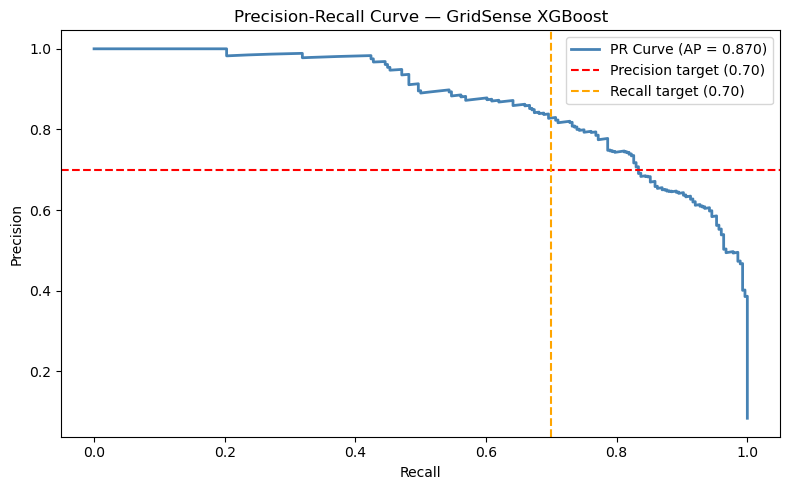

PR curve saved to pr_curve.png


In [14]:
# Precision-Recall Curve
precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions, color='steelblue', lw=2,
         label=f'PR Curve (AP = {avg_prec:.3f})')
plt.axhline(y=0.70, color='red',    linestyle='--', label='Precision target (0.70)')
plt.axvline(x=0.70, color='orange', linestyle='--', label='Recall target (0.70)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — GridSense XGBoost')
plt.legend()
plt.tight_layout()
plt.savefig('pr_curve.png', dpi=150)
plt.show()
print('PR curve saved to pr_curve.png')

### 8.1 Threshold Tuning

If recall falls below 0.70, lower the threshold to capture more true positives at the cost of some precision.

In [15]:
print(f'{"Threshold":>12} | {"Precision":>10} | {"Recall":>8} | {"F1":>8}')
print('-' * 48)
for t in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
    yp = (y_prob >= t).astype(int)
    p  = precision_score(y_true, yp, zero_division=0)
    r  = recall_score(y_true, yp, zero_division=0)
    f  = f1_score(y_true, yp, zero_division=0)
    print(f'{t:>12.2f} | {p:>10.4f} | {r:>8.4f} | {f:>8.4f}')

   Threshold |  Precision |   Recall |       F1
------------------------------------------------
        0.30 |     0.8377 |   0.6920 |   0.7579
        0.35 |     0.8455 |   0.6739 |   0.7500
        0.40 |     0.8592 |   0.6630 |   0.7485
        0.45 |     0.8713 |   0.6377 |   0.7364
        0.50 |     0.8737 |   0.6014 |   0.7124
        0.55 |     0.8736 |   0.5761 |   0.6943
        0.60 |     0.8807 |   0.5616 |   0.6858


## 9. Feature Importance

=== Top 15 Features by Gain ===
            feature       gain
        temperature 262.003357
      ghi_deviation 174.663086
   ghi_baseline_30d 107.022713
          month_cos 102.947243
           hour_cos  64.729347
           hour_sin  50.679108
          month_sin  37.564045
                dhi  27.284042
shortwave_radiation  25.761703
       cloud_type_0  15.156565
        day_of_week  14.567738
      windspeed_10m  14.167059
         cloudcover  11.792616
       cloud_type_1  11.225492
     windspeed_100m   8.559398


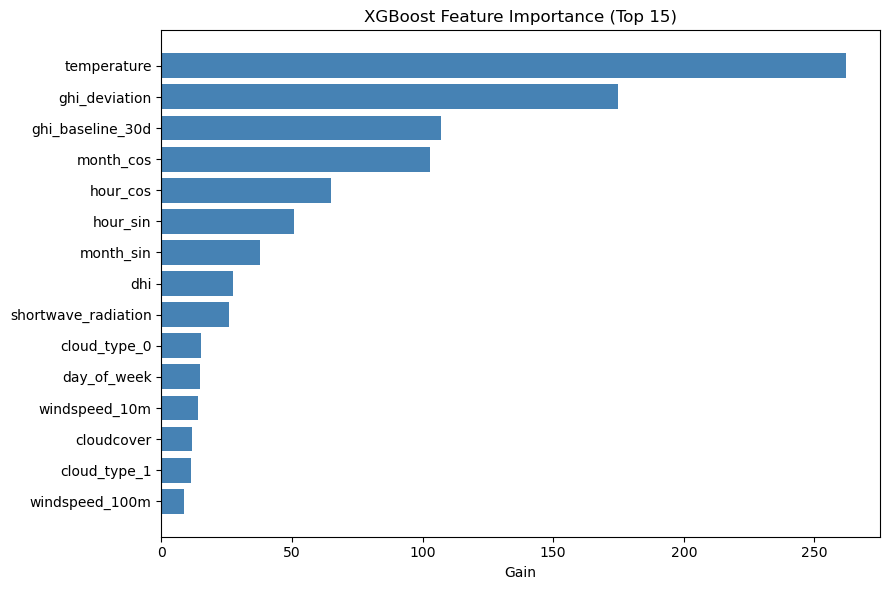

In [16]:
# bst already loaded in Section 7 — reuse it here
feature_names = [c for c in train_df.columns if c != TARGET]
scores = bst.get_score(importance_type='gain')

importance_df = pd.DataFrame(
    [(feature_names[int(k.replace('f', ''))], v) for k, v in scores.items()],
    columns=['feature', 'gain']
).sort_values('gain', ascending=False)

print('=== Top 15 Features by Gain ===')
print(importance_df.head(15).to_string(index=False))

plt.figure(figsize=(9, 6))
plt.barh(importance_df['feature'].head(15)[::-1],
         importance_df['gain'].head(15)[::-1],
         color='steelblue')
plt.xlabel('Gain')
plt.title('XGBoost Feature Importance (Top 15)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

## 10. Save Results Summary

In [17]:
results = {
    'job_name': job_name,
    'model_artifact': xgb_estimator.model_data,
    'threshold': THRESHOLD,
    'precision': round(prec, 4),
    'recall':    round(rec,  4),
    'f1':        round(f1,   4),
    'roc_auc':   round(roc_auc, 4),
    'avg_precision_score': round(avg_prec, 4),
    'train_aucpr': train_aucpr,
    'val_aucpr':   val_aucpr,
    'goal_precision_met': prec >= 0.70,
    'goal_recall_met':    rec  >= 0.70
}

with open('training_results.json', 'w') as f:
    json.dump(results, f, indent=2)

# Upload results JSON to S3
boto3.client('s3').upload_file('training_results.json', BUCKET, f'{OUTPUT_PREFIX}/training_results.json')

print('=== Training Results Summary ===')
print(json.dumps(results, indent=2))

=== Training Results Summary ===
{
  "job_name": "gridsense-xgb-1774812178",
  "model_artifact": "s3://gridsense-ai-data-team1-michaelha-2026/gridsense/models/gridsense-xgb-1774812178/output/model.tar.gz",
  "threshold": 0.5,
  "precision": 0.8737,
  "recall": 0.6014,
  "f1": 0.7124,
  "roc_auc": 0.9853,
  "avg_precision_score": 0.8704,
  "train_aucpr": 0.9994699954986572,
  "val_aucpr": 0.8924099802970886,
  "goal_precision_met": true,
  "goal_recall_met": false
}


---
## Summary

| Item | Detail |
|---|---|
| Algorithm | SageMaker Built-in XGBoost 1.7-1 |
| Objective | `binary:logistic` |
| Instance | `ml.m5.xlarge` (1×) |
| Key HP | max_depth=6, eta=0.1, scale_pos_weight=computed |
| Eval Metric | AUC-PR (Area Under Precision-Recall Curve) |
| Target | Precision ≥ 0.70, Recall ≥ 0.70 |
